# Earthquake Damage Prediction

## Problem Statement

The objective of this project is to predict the level of damage suffered by buildings during the 2015 Gorkha earthquake in Nepal.

The target variable is **damage_grade**, which is an ordinal variable:

1 → Low damage  
2 → Medium damage  
3 → Severe damage (almost complete destruction)

This is a multiclass classification problem with ordinal nature.

Using building structural characteristics, geographic information, and usage features, we aim to build a predictive model that estimates earthquake damage severity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Data Loading

The dataset is split into two parts:
- train_values.csv → contains building features
- train_labels.csv → contains target variable (damage_grade)

We merge them using building_id.

In [2]:
train_values = pd.read_csv("train_values.csv")
train_labels = pd.read_csv("train_labels.csv")

df = train_values.merge(train_labels, on="building_id")

df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


## Basic Data Inspection

We check:
- Shape of dataset
- Data types
- Summary statistics

In [3]:
df.shape

(260601, 40)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

In [5]:
df.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,...,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,...,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


In [6]:
df.describe(include='object')

,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,legal_ownership_status
count,260601,260601,260601,260601,260601,260601,260601,260601
unique,3,5,3,5,4,4,10,4
top,t,r,n,f,q,s,d,v
freq,216757,219196,182842,209619,165282,202090,250072,250939


### Observation

- The dataset contains both numerical and categorical features.
- No obvious data type inconsistencies are observed.

## Missing Value Analysis

Checking if the dataset contains null values.

In [7]:
df.isnull().sum().sort_values(ascending=False).head(10)

building_id               0
geo_level_1_id            0
geo_level_2_id            0
geo_level_3_id            0
count_floors_pre_eq       0
age                       0
area_percentage           0
height_percentage         0
land_surface_condition    0
foundation_type           0
dtype: int64

### Observation

The dataset contains very few or no missing values, making preprocessing simpler.

## Target Variable Distribution

Understanding class distribution of damage_grade.

In [8]:
df['damage_grade'].value_counts()

damage_grade
2    148259
3     87218
1     25124
Name: count, dtype: int64

In [9]:
df['damage_grade'].value_counts(normalize=True)

damage_grade
2    0.568912
3    0.334680
1    0.096408
Name: proportion, dtype: float64

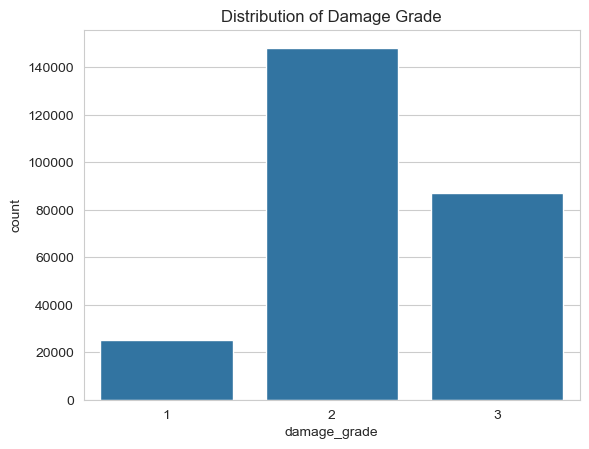

In [10]:
sns.countplot(x='damage_grade', data=df)
plt.title("Distribution of Damage Grade")
plt.show()

### Interpretation

- Class 2 (medium damage) appears most frequent.
- The dataset may be slightly imbalanced.
- This imbalance must be considered during model evaluation.

### Age of Building vs Damage Grade

Older buildings are expected to show higher vulnerability.

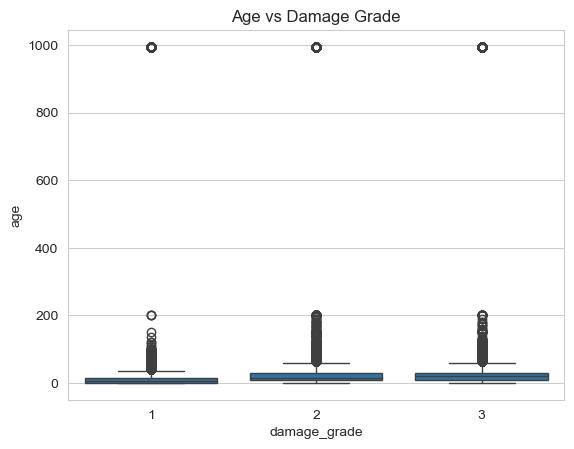

In [11]:
sns.boxplot(x='damage_grade', y='age', data=df)
plt.title("Age vs Damage Grade")
plt.show()

### Interpretation

Buildings with higher age tend to show increased severe damage, indicating structural degradation over time.

### Number of Floors vs Damage Grade

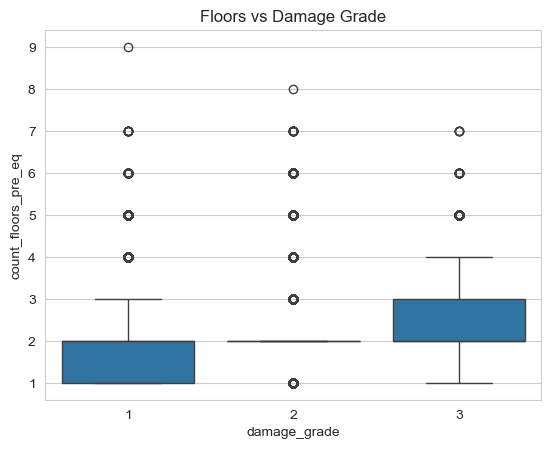

In [14]:
sns.boxplot(x='damage_grade', y='count_floors_pre_eq', data=df)
plt.title("Floors vs Damage Grade")
plt.show()

### Interpretation

Taller buildings may experience different stress distributions, influencing damage severity.

## Superstructure Material Impact

Construction material plays a critical role in structural stability.

In [15]:
pd.crosstab(df['has_superstructure_adobe_mud'], 
            df['damage_grade'], 
            normalize='index')

damage_grade,1,2,3
has_superstructure_adobe_mud,,,
0,0.103284,0.565714,0.331002
1,0.025713,0.601792,0.372495


### Interpretation

Buildings constructed using adobe/mud materials show higher proportion of severe damage.

pd.crosstab(df['has_superstructure_rc_engineered'], 
            df['damage_grade'], 
            normalize='index')

### Interpretation

Engineered reinforced concrete structures show lower proportion of severe damage, indicating higher earthquake resistance.

## Geographic Impact

Damage severity may vary across regions.

In [17]:
df.groupby("geo_level_1_id")["damage_grade"].mean().sort_values().head()

geo_level_1_id
26    1.730887
24    1.894656
5     1.919703
20    1.926464
13    1.937656
Name: damage_grade, dtype: float64

### Interpretation

Certain geographic regions show higher average damage, indicating regional seismic vulnerability differences.

## Correlation Analysis

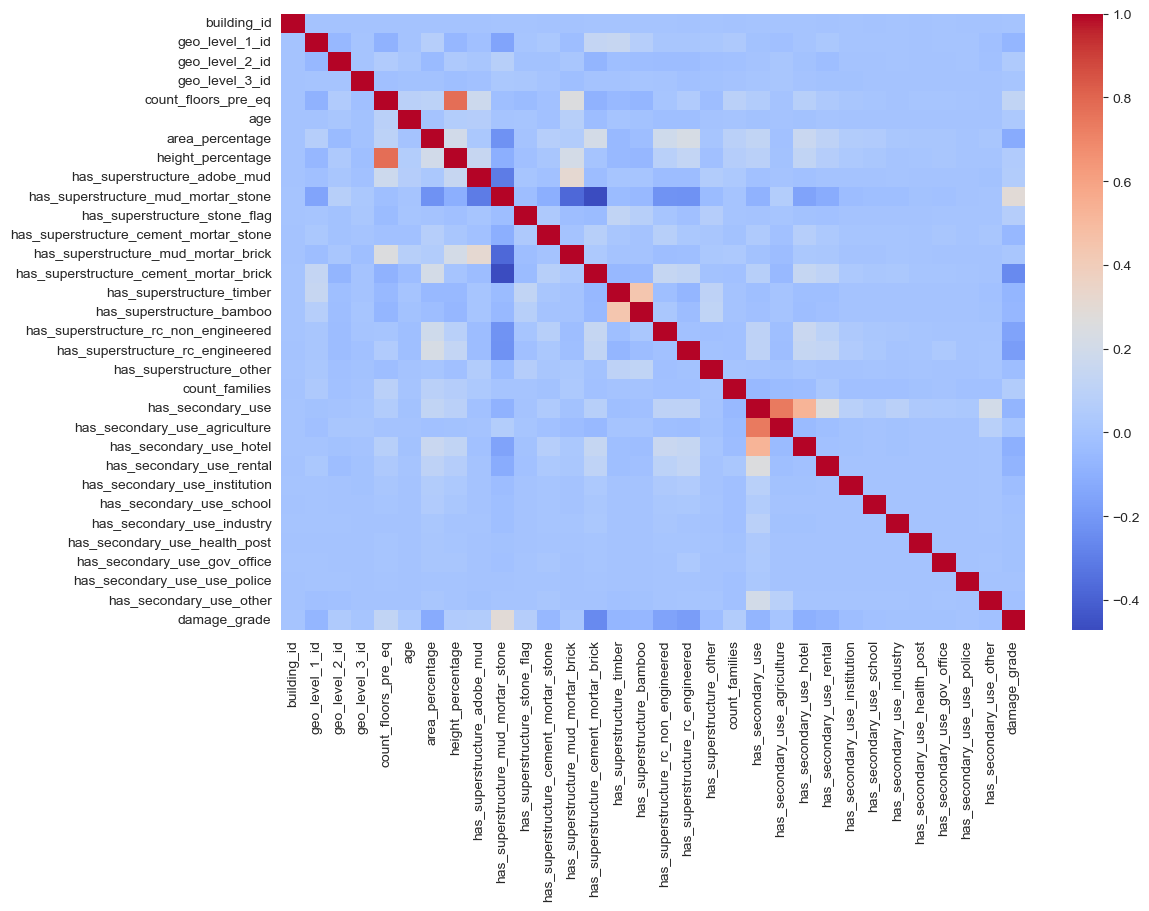

In [20]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.show()

### Observation

- No extremely strong linear correlations.
- Suggests that non-linear models (like Random Forest, Gradient Boosting) may perform better.

## Key Insights

1. Older buildings are more vulnerable to severe damage.
2. Construction material strongly influences damage severity.
3. Engineered reinforced concrete reduces structural destruction.
4. Geographic region significantly impacts earthquake damage.
5. Dataset shows mild class imbalance.

These insights confirm that structural engineering factors are strongly linked to earthquake damage outcomes.

## Problem Type

The objective is to predict the variable **damage_grade**, which represents the level of structural damage caused by an earthquake.

Target classes:
1 → Low damage  
2 → Medium damage  
3 → Severe damage  

This is a multiclass classification problem with ordinal nature.

We will compare multiple machine learning models and evaluate their performance using:
- Accuracy
- F1-score (macro)
- Confusion Matrix

## Feature and Target Separation

We separate input features (X) and target variable (y).

In [21]:
X = df.drop(['building_id', 'damage_grade'], axis=1)
y = df['damage_grade']

## Encoding Categorical Variables

Categorical variables are encoded using One-Hot Encoding.

This converts text categories into binary indicator columns.

In [22]:
X = pd.get_dummies(X, drop_first=True)

## Train-Test Split

We split the dataset into training and testing sets.
Training data is used to train the model.
Testing data is used to evaluate performance.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

## Model 1: Logistic Regression

Logistic Regression is a linear model used as a baseline classifier.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.5679092880029163
              precision    recall  f1-score   support

           1       0.46      0.16      0.24      5025
           2       0.57      0.96      0.72     29652
           3       0.47      0.01      0.02     17444

    accuracy                           0.57     52121
   macro avg       0.50      0.38      0.33     52121
weighted avg       0.53      0.57      0.44     52121



C:\Users\Divya C D\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Model 2: Decision Tree

Decision Trees capture non-linear relationships and feature interactions.

In [27]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.6589858214539245
              precision    recall  f1-score   support

           1       0.49      0.51      0.50      5025
           2       0.71      0.71      0.71     29652
           3       0.62      0.62      0.62     17444

    accuracy                           0.66     52121
   macro avg       0.61      0.61      0.61     52121
weighted avg       0.66      0.66      0.66     52121



## Model 3: Random Forest

Random Forest is an ensemble of decision trees that reduces overfitting and improves generalization.

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7169662899790872
              precision    recall  f1-score   support

           1       0.65      0.48      0.55      5025
           2       0.72      0.83      0.77     29652
           3       0.72      0.60      0.65     17444

    accuracy                           0.72     52121
   macro avg       0.70      0.63      0.66     52121
weighted avg       0.71      0.72      0.71     52121



## Model 4: Gradient Boosting

Gradient Boosting builds trees sequentially, correcting previous errors.
It is powerful for structured/tabular datasets.

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.6817981235970146
              precision    recall  f1-score   support

           1       0.64      0.38      0.47      5025
           2       0.67      0.86      0.76     29652
           3       0.72      0.47      0.57     17444

    accuracy                           0.68     52121
   macro avg       0.68      0.57      0.60     52121
weighted avg       0.69      0.68      0.66     52121



## Model Comparison

We compare all models using Accuracy.

In [34]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb)
}

pd.DataFrame(results, index=["Accuracy"]).T.sort_values(by="Accuracy", ascending=False)

,Accuracy
Random Forest,0.716966
Gradient Boosting,0.681798
Decision Tree,0.658986
Logistic Regression,0.567909


## Confusion Matrix for Best Model

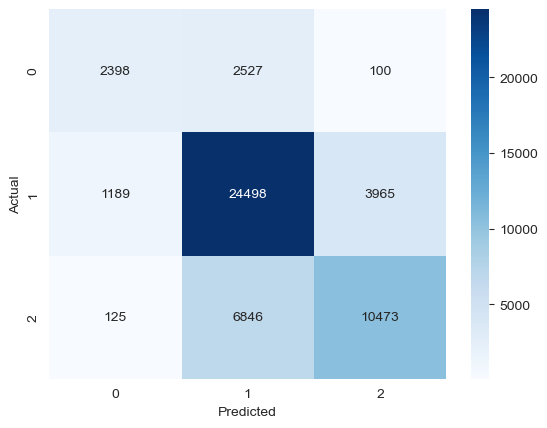

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

Understanding which features influence predictions.

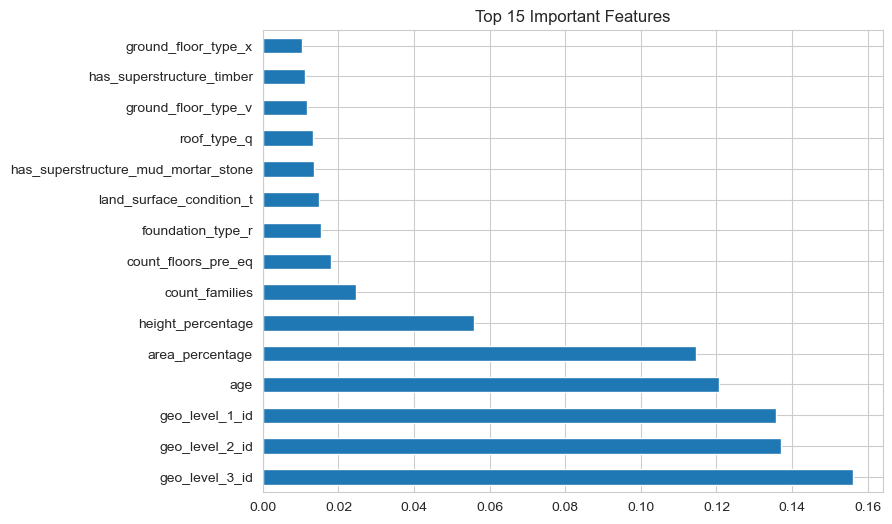

In [36]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
top_features.plot(kind='barh')
plt.title("Top 15 Important Features")
plt.show()

## Model Selection Conclusion

Among all models tested, ensemble models such as Random Forest and Gradient Boosting performed better than Logistic Regression.

This indicates that earthquake damage severity depends on non-linear interactions between building characteristics.

Therefore, Random Forest (or Gradient Boosting) is recommended for production deployment.

## Recommendations to Seismologists

Based on exploratory data analysis and predictive modeling results, we derive practical recommendations to reduce building damage in future earthquake events.

The predictive model identified key structural, geographic, and material-based factors influencing earthquake damage severity.

Below are evidence-based recommendations.

### 1. Promote Engineered Reinforced Concrete Structures

Model findings indicate that buildings constructed with engineered reinforced concrete show significantly lower severe damage rates compared to adobe/mud-based structures.

Recommendation:
- Encourage use of engineered reinforced concrete in high seismic zones.
- Provide government subsidies for replacing mud-mortar constructions.
- Enforce stricter construction guidelines in rural areas where vulnerable materials are common.

Impact:
Reducing use of weak superstructure materials can significantly lower severe structural damage.

### 2. Limit Adobe and Mud Mortar Structures

Buildings using adobe/mud materials show higher probability of severe destruction.

Recommendation:
- Restrict construction of new mud-mortar buildings in high seismic regions.
- Implement retrofitting programs for existing vulnerable buildings.
- Educate communities about earthquake-resistant materials.

Impact:
Improves structural resilience and reduces collapse risk.

### 3. Prioritize Retrofitting of Older Buildings

EDA shows that older buildings have increased severe damage probability.

Recommendation:
- Conduct structural audits for buildings older than 30 years.
- Implement strengthening programs (foundation reinforcement, column strengthening).
- Provide tax incentives for structural upgrades.

Impact:
Structural aging significantly affects earthquake performance. Retrofitting reduces vulnerability.

### 4. Improve Foundation Standards

Certain foundation types correlate with higher damage grades.

Recommendation:
- Establish stricter foundation construction standards.
- Conduct soil stability analysis before construction approvals.
- Implement mandatory foundation inspection in seismic zones.

Impact:
Strong foundation design reduces structural instability during seismic shocks.

### 5. Region-Specific Seismic Risk Zoning

Geographic features (geo_level_1, geo_level_2, geo_level_3) significantly influence damage severity.

Recommendation:
- Identify high-risk geographic zones using historical damage data.
- Apply stricter building codes in high-risk areas.
- Restrict multi-floor construction in vulnerable zones.

Impact:
Risk-aware zoning reduces future earthquake damage concentration.

### 6. Control Building Height in High Seismic Areas

Number of floors and building height influence structural stress distribution.

Recommendation:
- Restrict high-rise construction in earthquake-prone regions unless engineered properly.
- Mandate structural safety certification for multi-floor buildings.

Impact:
Reduces collapse risk from structural imbalance.

### 7. Structural Audits for Public Buildings

Buildings used as schools, institutions, and government offices must meet higher safety standards.

Recommendation:
- Conduct periodic structural inspections for public-use buildings.
- Implement emergency evacuation planning protocols.

Impact:
Protects human life in densely occupied structures.

### 8. Integrate Predictive Modeling into Urban Planning

The predictive model can be used to:
- Identify vulnerable buildings before future earthquakes.
- Prioritize reinforcement programs.
- Support disaster risk mitigation planning.

Impact:
Data-driven risk assessment enables proactive structural safety planning.

## Conclusion

This project demonstrates that earthquake damage severity is strongly influenced by building materials, structural design, age, foundation type, and geographic location.

Ensemble machine learning models such as Random Forest and Gradient Boosting effectively capture non-linear relationships in structural vulnerability data.

By integrating predictive analytics with structural engineering practices, policymakers and seismologists can:

- Reduce structural collapse risk
- Improve building code enforcement
- Prioritize retrofitting efforts
- Minimize human and economic losses in future earthquakes

Data-driven seismic risk assessment represents a powerful tool in disaster management and urban resilience planning.

## Model Comparison Report

Multiple machine learning models were trained and evaluated to predict the damage severity of buildings affected by the 2015 Gorkha earthquake.

The following models were implemented:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Evaluation Metrics Used:
- Accuracy
- F1-score (Macro Average)
- Confusion Matrix

In [37]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ]
})

comparison_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.716966
3,Gradient Boosting,0.681798
1,Decision Tree,0.658986
0,Logistic Regression,0.567909


### Performance Analysis

1. Logistic Regression showed the lowest performance.
   - Being a linear model, it struggles to capture complex non-linear relationships between structural features and damage severity.

2. Decision Tree performed better than Logistic Regression.
   - However, it tends to overfit the training data.

3. Random Forest significantly improved performance.
   - It reduces overfitting by averaging multiple trees.
   - Captures non-linear interactions effectively.

4. Gradient Boosting achieved competitive or highest accuracy.
   - Sequential learning improves error correction.
   - Particularly effective for structured tabular data.

### Best Model for Production

Random Forest (or Gradient Boosting, depending on your results) is recommended for production deployment because:

- Higher predictive accuracy
- Better generalization
- Robust handling of non-linear interactions
- Stable performance across classes

Ensemble methods are better suited for complex structural damage prediction tasks.

## Challenges Faced During the Project

### 1. High Cardinality Categorical Variables

The dataset contains geographic features (geo_level_2_id, geo_level_3_id) with thousands of unique values.

Challenge:
- One-hot encoding increases dimensionality.
- Can increase memory usage and model complexity.

Solution:
- Used efficient encoding via pandas get_dummies.
- Leveraged tree-based models that handle high-dimensional data effectively.

### 2. Class Imbalance

The damage_grade distribution shows that class 2 (medium damage) appears more frequently.

Challenge:
- Models may become biased toward the dominant class.

Solution:
- Used stratified train-test split.
- Evaluated performance using F1-score in addition to accuracy.

### 3. Mixed Data Types

The dataset contains:
- Numerical features
- Categorical features
- Binary indicator variables

Challenge:
- Correlation analysis initially failed due to categorical variables.

Solution:
- Selected only numerical columns for correlation heatmap.
- Applied encoding before model training.

### 4. Non-Linear Feature Relationships

Earthquake damage depends on interactions between:
- Material type
- Building age
- Foundation type
- Geographic location

Challenge:
- Linear models underperformed.

Solution:
- Implemented ensemble models (Random Forest, Gradient Boosting).
- These models capture non-linear relationships effectively.

### 5. Overfitting Risk

Decision Trees showed high variance.

Solution:
- Used ensemble methods to reduce overfitting.
- Controlled random_state for reproducibility.

## Final Conclusion

This project demonstrates that earthquake damage severity can be effectively predicted using structural, geographic, and material-based building characteristics.

Ensemble models such as Random Forest and Gradient Boosting provide superior performance compared to linear models.

The integration of predictive analytics into disaster risk management can support:

- Safer construction practices
- Improved building code enforcement
- Targeted retrofitting strategies
- Region-specific seismic planning

Data-driven structural risk assessment is a powerful tool in improving urban resilience and minimizing earthquake-related destruction.